In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [2]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r
import random
import harmonypy as hm
import anndata2ri

In [3]:
sc.settings.seed = 42
np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

In [4]:
adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/adata_after_cell_annotation.h5ad")

In [5]:
%load_ext rpy2.ipython

In [7]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,leiden_res0_25,leiden_res0_5,leiden_res1,leiden_res2,leiden_res0_3,leiden_res0_4,leiden_res0_6,leiden_res0_7,leiden_res0_8,manual_celltype_annotation
AAACCAAAGCGCCTGA-1-S26_17,1741,7.462789,2887.0,7.968319,15.587115,21.440942,27.779702,37.062695,57.014202,28.0,...,0,0,0,0,0,0,0,0,0,fibroblasts
AAACCAAAGGCGAGAC-1-S26_17,1458,7.285507,2360.0,7.766840,14.745763,20.932203,28.093220,38.474576,59.406780,32.0,...,0,3,2,0,0,6,1,4,0,fibroblasts
AAACCAAAGGCTCCGA-1-S26_17,2520,7.832411,5668.0,8.642768,18.719125,25.723359,32.163020,40.508116,56.527876,48.0,...,3,7,9,3,6,3,5,5,4,cardiomyocytes
AAACCAAAGGTGCAGA-1-S26_17,886,6.787845,1103.0,7.006695,10.063463,17.225748,26.291931,37.805984,65.004533,16.0,...,2,9,5,6,3,4,6,7,7,cardiomyocytes
AAACCAAAGTCGCATA-1-S26_17,1109,7.012115,1730.0,7.456455,14.104046,21.502890,30.635838,42.890173,64.797688,32.0,...,4,4,15,11,1,12,3,12,11,endothel cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTTAGCCCA-1-S26_32,755,6.628041,1182.0,7.075809,14.720812,24.619289,35.109983,52.030457,78.426396,7.0,...,4,4,13,18,1,12,12,12,11,endothel cells
TGTGTTAGTAGGTCCC-1-S26_32,2209,7.700748,4861.0,8.489205,16.251800,22.197079,29.129809,38.407735,55.996708,38.0,...,0,0,0,2,0,0,0,0,0,fibroblasts
TGTGTTAGTATGTCCG-1-S26_32,1395,7.241366,2239.0,7.714231,9.870478,16.971862,25.279142,37.114783,60.026798,37.0,...,4,4,16,13,1,12,3,12,11,endothel cells
TGTGTTAGTTAACCCG-1-S26_32,721,6.582025,1021.0,6.929517,14.397649,24.191969,34.769833,48.971596,78.354554,21.0,...,2,9,5,8,3,4,6,7,7,cardiomyocytes


In [6]:
adata.obs["condition"] = adata.obs["condition"].astype("category")
adata.obs["sample"] = adata.obs["sample"].astype("category")
# leiden_res0_25 for myeloid, is called differently here
# need cluster/cell type identity
adata.obs["manual_celltype_annotation"] = adata.obs["manual_celltype_annotation"].astype("category")

## Function to create pseudobulks per cell type and sample

In [7]:
NUM_OF_CELL_PER_DONOR = 30


def aggregate_and_filter(
    adata,
    cell_identity,
    donor_key,
    condition_key,
    cell_identity_key,
    obs_to_keep=None,  # which additional metadata to keep, e.g. gender, age, etc.
    replicates_per_patient=1,
):
    # subset adata to the given cell identity
    if obs_to_keep is None:
        obs_to_keep = []
    adata_cell_pop = adata[adata.obs[cell_identity_key] == cell_identity].copy()
    # check which donors to keep according to the number of cells specified with NUM_OF_CELL_PER_DONOR
    size_by_donor = adata_cell_pop.obs.groupby([donor_key]).size()
    donors_to_drop = [
        donor
        for donor in size_by_donor.index
        if size_by_donor[donor] <= NUM_OF_CELL_PER_DONOR
    ]
    if len(donors_to_drop) > 0:
        print("Dropping the following samples:")
        print(donors_to_drop)
    df = pd.DataFrame(columns=[*adata_cell_pop.var_names, *obs_to_keep])

    adata_cell_pop.obs[donor_key] = adata_cell_pop.obs[donor_key].astype("category")
    for i, donor in enumerate(donors := adata_cell_pop.obs[donor_key].cat.categories):
        print(f"\tProcessing donor {i+1} out of {len(donors)}...", end="\r")
        if donor not in donors_to_drop:
            adata_donor = adata_cell_pop[adata_cell_pop.obs[donor_key] == donor]
            # create replicates for each donor
            indices = list(adata_donor.obs_names)
            random.shuffle(indices)
            indices = np.array_split(np.array(indices), replicates_per_patient)
            for i, rep_idx in enumerate(indices):
                adata_replicate = adata_donor[rep_idx]
                # specify how to aggregate: sum gene expression for each gene for each donor and also keep the condition information
                agg_dict = dict.fromkeys(adata_replicate.var_names, "sum")
                for obs in obs_to_keep:
                    agg_dict[obs] = "first"
                # create a df with all genes, donor and condition info
                df_donor = pd.DataFrame(adata_replicate.X.toarray())
                df_donor.index = adata_replicate.obs_names
                df_donor.columns = adata_replicate.var_names
                df_donor = df_donor.join(adata_replicate.obs[obs_to_keep])
                # aggregate
                df_donor = df_donor.groupby(donor_key).agg(agg_dict)
                df_donor[donor_key] = donor
                df.loc[f"donor_{donor}_{i}"] = df_donor.loc[donor]
    print("\n")
    # create AnnData object from the df
    adata_cell_pop = sc.AnnData(
        df[adata_cell_pop.var_names], obs=df.drop(columns=adata_cell_pop.var_names)
    )
    return adata_cell_pop

In [8]:
obs_to_keep = ["manual_celltype_annotation", "condition", "sample"]
adata.X = adata.layers["soupX_counts"].copy()
cell_type = adata.obs["manual_celltype_annotation"].cat.categories[0]

In [11]:
cell_type

'cardiomyocytes'

In [14]:
adata

AnnData object with n_obs × n_vars = 111118 × 20681
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'soupx_groups', 'scDblFinder_score', 'scDblFinder_class', 'sample', 'condition', 'size_factors', 'leiden', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'leiden_res0_3', 'leiden_res0_4', 'leiden_res0_6', 'leiden_res0_7', 'leiden_res0_8', 'manual_celltype_annotation'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', '

## Run pseudobulking

In [9]:
# process first cell type separately...
cell_type = adata.obs["manual_celltype_annotation"].cat.categories[0]
print(
    f'Processing {cell_type} (1 out of {len(adata.obs["manual_celltype_annotation"].cat.categories)})...'
)
adata_pb = aggregate_and_filter(adata,
    cell_type,
    "sample",
    "condition",
    "manual_celltype_annotation",
    replicates_per_patient=1, obs_to_keep=obs_to_keep)
for i, cell_type in enumerate(adata.obs["manual_celltype_annotation"].cat.categories[1:]):
    print(
        f'Processing {cell_type} ({i+2} out of {len(adata.obs["manual_celltype_annotation"].cat.categories)})...'
    )
    adata_cell_type = aggregate_and_filter(adata,
    cell_type,
    "sample",
    "condition",
    "manual_celltype_annotation",
    replicates_per_patient=1, obs_to_keep=obs_to_keep)
    adata_pb = adata_pb.concatenate(adata_cell_type)

Processing cardiomyocytes (1 out of 8)...


/tmp/ipykernel_3176355/509313728.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_by_donor = adata_cell_pop.obs.groupby([donor_key]).size()


/tmp/ipykernel_3176355/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_3176355/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_3176355/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


...

/tmp/ipykernel_3176355/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_3176355/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_3176355/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_3176355/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_3176355/1278382446.py:22: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_pb = adata_pb.concatenate(adata_cell_type)


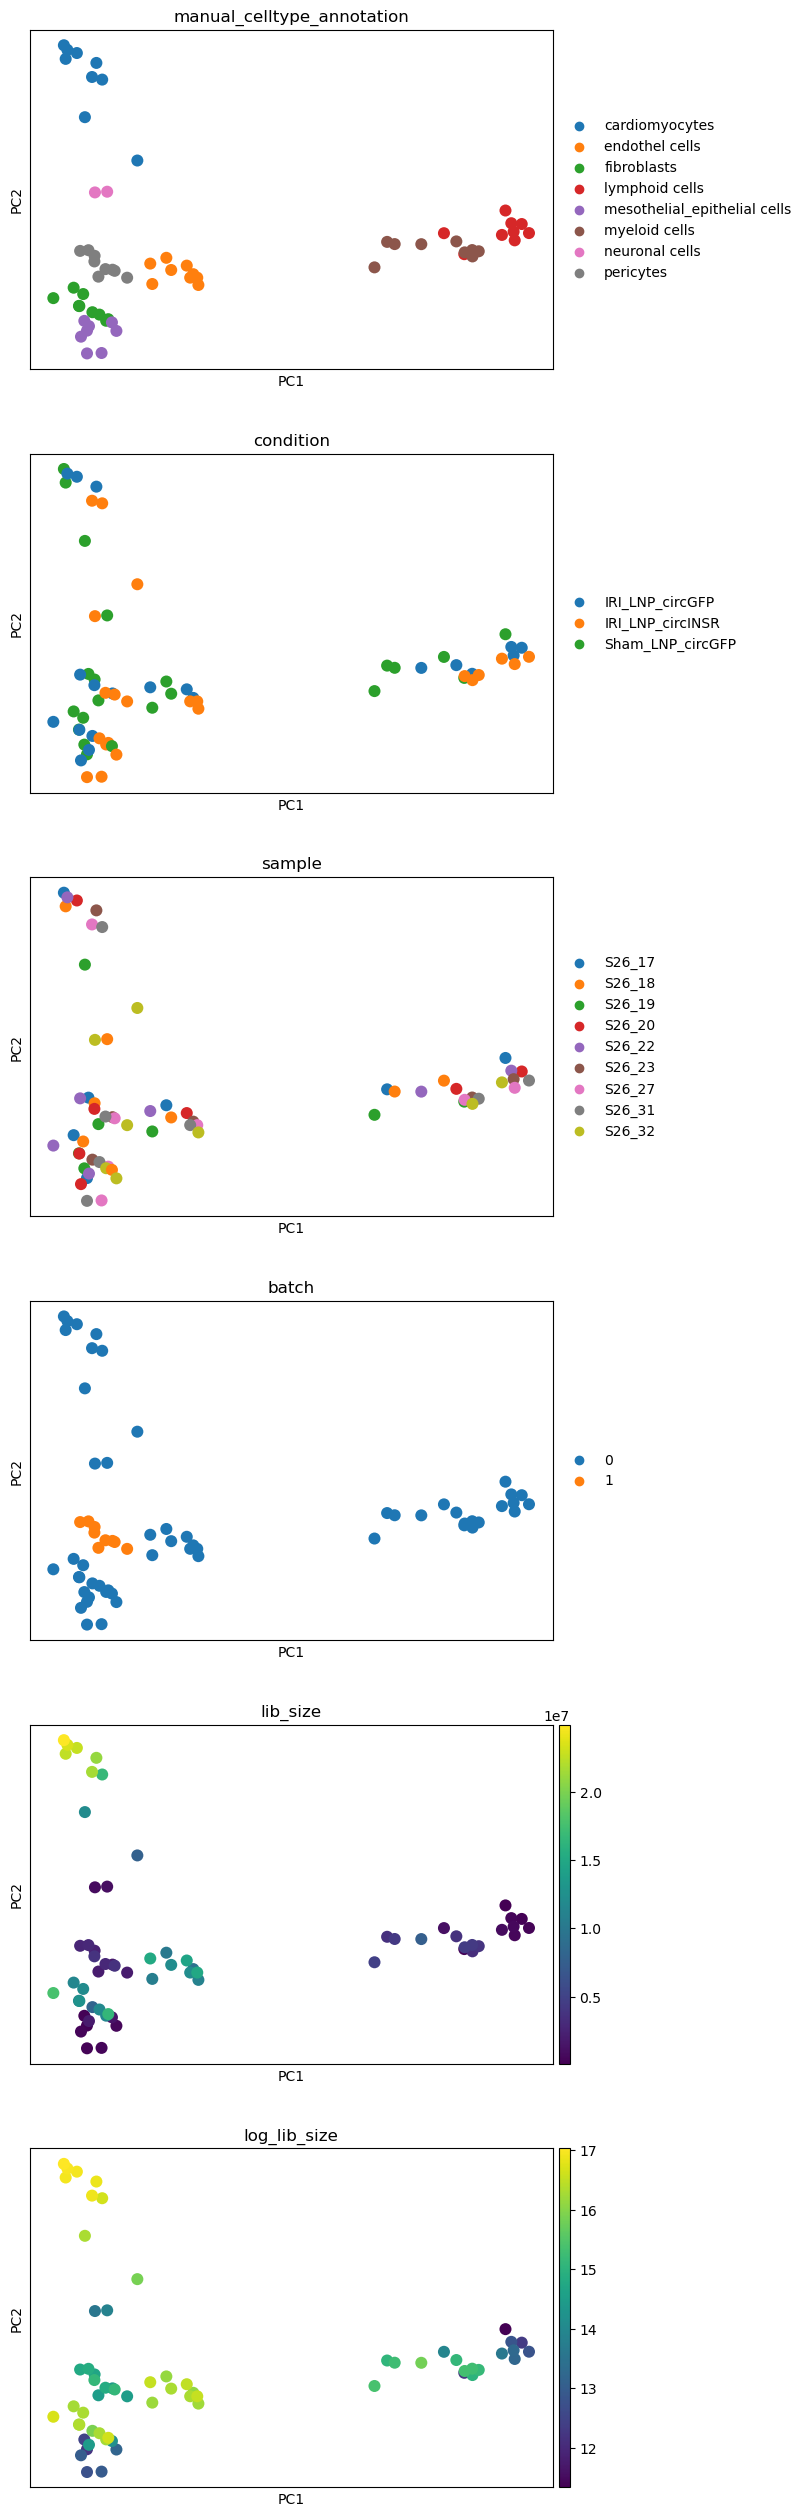

In [10]:
# we are working with soupx counts, assigned to counts
adata_pb.layers['counts'] = adata_pb.X.copy().astype(float)
sc.pp.normalize_total(adata_pb, target_sum=1e6)
sc.pp.log1p(adata_pb)
sc.pp.pca(adata_pb)
adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1).astype(float)
adata_pb.obs["log_lib_size"] = np.log(adata_pb.obs["lib_size"].astype(float))
sc.pl.pca(adata_pb, color=adata_pb.obs, ncols=1, size=300)

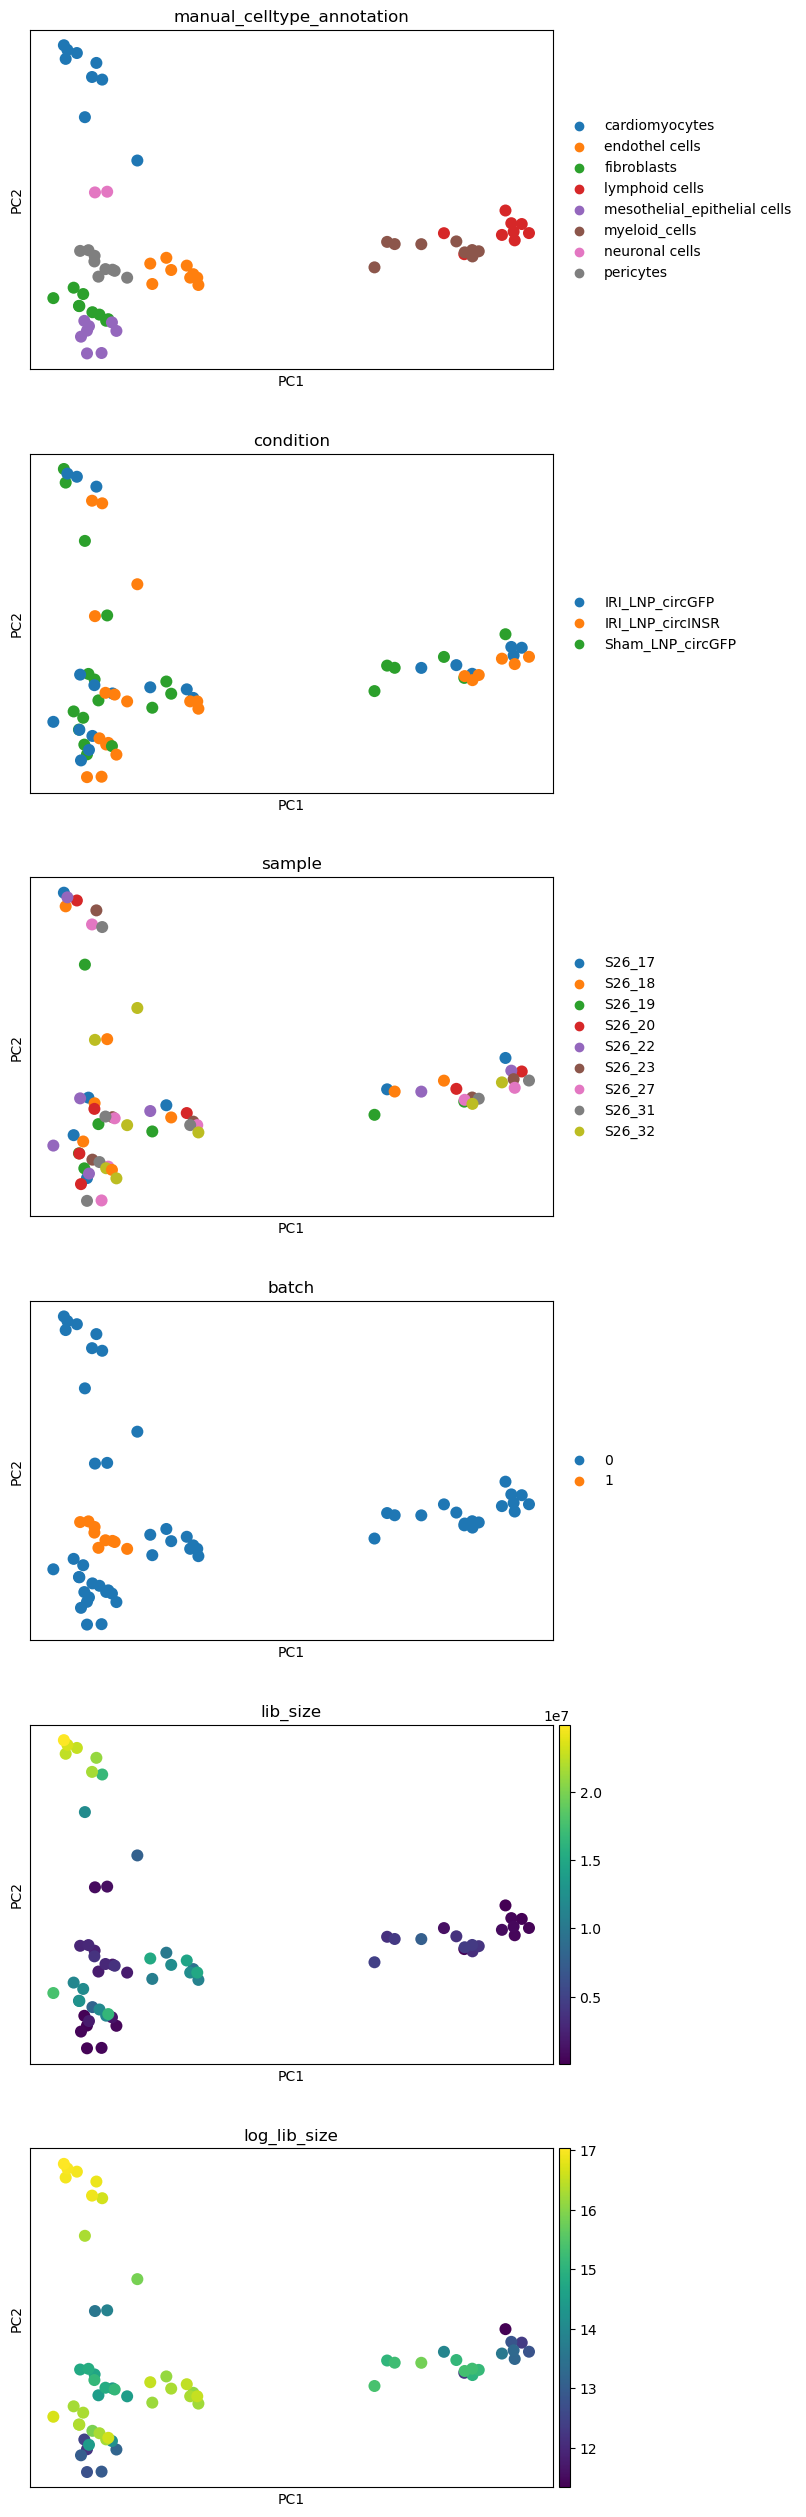

In [96]:
sc.pl.pca(adata_pb, color=adata_pb.obs, ncols=1, size=300, show = False)
plt.savefig("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/Pseudobulk_all_celltypes_plot.png")

In [11]:
# edgeR requires raw counts!
# we normalized .X, so we need to reset to raw counts
adata_pb.X = adata_pb.layers['counts'].copy()

In [12]:
os.makedirs("/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster", exist_ok = True)
adata_pb.write("/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/adata_pseudobulk.h5ad")

# Iterate through each cell type for DEG testing

In [13]:
adata_pb.obs["manual_celltype_annotation"]

donor_S26_17_0-0-0-0-0-0-0-0    cardiomyocytes
donor_S26_18_0-0-0-0-0-0-0-0    cardiomyocytes
donor_S26_19_0-0-0-0-0-0-0-0    cardiomyocytes
donor_S26_20_0-0-0-0-0-0-0-0    cardiomyocytes
donor_S26_22_0-0-0-0-0-0-0-0    cardiomyocytes
                                     ...      
donor_S26_22_0-1                     pericytes
donor_S26_23_0-1                     pericytes
donor_S26_27_0-1                     pericytes
donor_S26_31_0-1                     pericytes
donor_S26_32_0-1                     pericytes
Name: manual_celltype_annotation, Length: 64, dtype: category
Categories (8, object): ['cardiomyocytes', 'endothel cells', 'fibroblasts', 'lymphoid cells', 'mesothelial_epithelial cells', 'myeloid cells', 'neuronal cells', 'pericytes']

In [ ]:
adata_pb.layers

Layers with keys: counts

## Celltype Cardiomyocytes

In [14]:
adata_pb_cardiomyocytes = adata_pb[adata_pb.obs["manual_celltype_annotation"]=="cardiomyocytes"]
adata_pb_cardiomyocytes.obs_names = [
    name.split("_")[1] + "_" + name.split("_")[2] for name in adata_pb_cardiomyocytes.obs_names
]

In [15]:
import anndata2ri
from rpy2.robjects import pandas2ri
%reload_ext rpy2.ipython
anndata2ri.set_ipython_converter()

In [16]:
%%R
fit_model <- function(adata_){
    # create an edgeR object with counts and grouping factor
    y <- DGEList(assay(adata_, "X"), group = colData(adata_)$condition)
    # filter out genes with low counts
    print("Dimensions before subsetting:")
    print(dim(y))
    keep <- filterByExpr(y)
    y <- y[keep, , keep.lib.sizes=FALSE]
    print("Dimensions after subsetting:")
    print(dim(y))
    # normalize
    y <- calcNormFactors(y)
    # create a vector that is a concatenation of condition and cell type that we will later use with contrasts
    group <- paste0(colData(adata_)$condition, ".", colData(adata_)$manual_celltype_annotation)
    print(group)
    # replicate nutze ich gar nicht, weil wir keine replicates vom sample haben -> wäre sonst überspezifiziert
    replicate <- colData(adata_)$sample
    # create a design matrix: here we have multiple donors so also consider that in the design matrix
    design <- model.matrix(~ 0 + group)
    print(design)
    # estimate dispersion
    y <- estimateDisp(y, design = design)
    # fit the model
    fit <- glmQLFit(y, design)
    return(list("fit"=fit, "design"=design, "y"=y))
}

In [17]:
%%time
%%R -i adata_pb_cardiomyocytes
library(edgeR)
outs <-fit_model(adata_pb_cardiomyocytes)




/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/functools.py:909: NotConvertedWarning: Conversion 'py2rpy' not defined for objects of type '<class 'NoneType'>'
  return dispatch(args[0].__class__)(*args, **kw)


[1] "Dimensions before subsetting:"
[1] 20681     9
[1] "Dimensions after subsetting:"
[1] 17109     9
[1] "Sham_LNP_circGFP.cardiomyocytes" "Sham_LNP_circGFP.cardiomyocytes"
[3] "Sham_LNP_circGFP.cardiomyocytes" "IRI_LNP_circGFP.cardiomyocytes" 
[5] "IRI_LNP_circGFP.cardiomyocytes"  "IRI_LNP_circGFP.cardiomyocytes" 
[7] "IRI_LNP_circINSR.cardiomyocytes" "IRI_LNP_circINSR.cardiomyocytes"
[9] "IRI_LNP_circINSR.cardiomyocytes"
  groupIRI_LNP_circGFP.cardiomyocytes groupIRI_LNP_circINSR.cardiomyocytes
1                                   0                                    0
2                                   0                                    0
3                                   0                                    0
4                                   1                                    0
5                                   1                                    0
6                                   1                                    0
7                                   0         

Loading required package: limma

Attaching package: ‘limma’

The following object is masked from ‘package:BiocGenerics’:

    plotMA


Attaching package: ‘edgeR’

The following objects are masked from ‘package:SingleCellExperiment’:

    cpm, tpm



CPU times: user 10.3 s, sys: 1.24 s, total: 11.6 s
Wall time: 28.2 s


In [18]:
%%R
fit <- outs$fit
y <- outs$y

In [19]:
%%R
print(fit)
print(y)

An object of class "DGEGLM"
$coefficients
              groupIRI_LNP_circGFP.cardiomyocytes
0610005C13Rik                           -12.24718
0610009B22Rik                           -11.58827
0610009E02Rik                           -10.89476
0610009L18Rik                           -12.25451
0610010K14Rik                           -12.40470
              groupIRI_LNP_circINSR.cardiomyocytes
0610005C13Rik                            -12.74558
0610009B22Rik                            -11.98087
0610009E02Rik                            -11.12458
0610009L18Rik                            -12.37412
0610010K14Rik                            -12.59902
              groupSham_LNP_circGFP.cardiomyocytes
0610005C13Rik                            -12.24757
0610009B22Rik                            -11.09186
0610009E02Rik                            -11.29102
0610009L18Rik                            -11.42954
0610010K14Rik                            -11.35106
17104 more rows ...

$fitted.values
          

In [97]:
%%R
png("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/Pseudobulk_multidimensional_scaling_cardiomyocytes_plot.png")
plotMDS(y, col=ifelse(y$samples$group == "Sham_LNP_circGFP",  "blue", ifelse(y$samples$group == "IRI_LNP_circGFP", "green", "red")))
dev.off()

png 
  2 


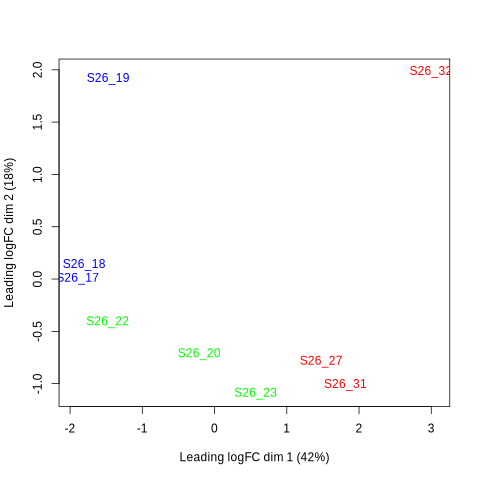

In [20]:
%%R
plotMDS(y, col=ifelse(y$samples$group == "Sham_LNP_circGFP",  "blue", ifelse(y$samples$group == "IRI_LNP_circGFP", "green", "red")))

In [98]:
%%R
png("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/Pseudobulk_biological_coefficient_of_variation_cardiomyocytes_plot.png")
plotBCV(y)
dev.off()

png 
  2 


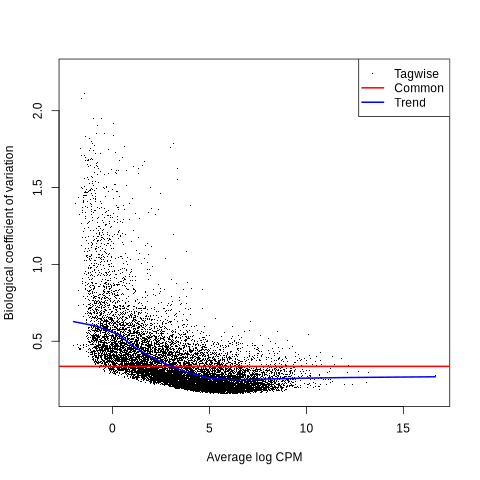

In [ ]:
%%R
plotBCV(y)

## Comparison cardiomyocyte (contrast) for IRI_LNP_circGFP vs Sham_LNP_circGFP

In [21]:
%%R -o tt
# run the test for a specififed contrast
myContrast <- makeContrasts('groupIRI_LNP_circGFP.cardiomyocytes-groupSham_LNP_circGFP.cardiomyocytes', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table

# filter the results for FDR and logFC
library(dplyr)
print(head(tt))
print(typeof(tt))
tt <- as.data.frame(tt)
print(head(tt))
print(dim(tt[tt$FDR < 0.01,]))

tt_filtered_up <- tt %>%
  filter(FDR < 0.05 & logFC > 1 )


tt_filtered_down <- tt %>%
  filter(FDR < 0.05 & logFC < -1)

# write results
write.csv(tt_filtered_up,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/cardiomyocytes/Cardiomyocytes_DEGs_UP_filtered_groupIRI_LNP_GFP.cardiomyocytes-groupSham_LNP_circGFP.cardiomyocytes.csv", row.names = TRUE)
write.csv(tt_filtered_down,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/cardiomyocytes/Cardiomyocytes_DEGs_down_filtered_groupIRI_LNP_GFP.cardiomyocytes-groupSham_LNP_circGFP.cardiomyocytes.csv", row.names = TRUE)
write.csv(tt,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/cardiomyocytes/Cardiomyocytes_DEGs_unfiltered_groupIRI_LNP_GFP.cardiomyocytes-groupSham_LNP_circGFP.cardiomyocytes.csv", row.names = TRUE)

                  logFC   logCPM        F       PValue        FDR
Lrfn4         -2.677475 2.787466 91.34180 1.625179e-06 0.01534949
Dvl1          -2.185936 4.713805 87.39688 1.939703e-06 0.01534949
Atf5          -2.652903 5.177922 81.57108 2.691476e-06 0.01534949
Meig1         -3.068587 1.968222 66.35833 5.268233e-06 0.01816116
1700025G04Rik  1.447218 6.584888 70.56327 5.307488e-06 0.01816116
Gm36220       -1.702196 4.682430 66.98185 6.762033e-06 0.01928194
[1] "list"
                  logFC   logCPM        F       PValue        FDR
Lrfn4         -2.677475 2.787466 91.34180 1.625179e-06 0.01534949
Dvl1          -2.185936 4.713805 87.39688 1.939703e-06 0.01534949
Atf5          -2.652903 5.177922 81.57108 2.691476e-06 0.01534949
Meig1         -3.068587 1.968222 66.35833 5.268233e-06 0.01816116
1700025G04Rik  1.447218 6.584888 70.56327 5.307488e-06 0.01816116
Gm36220       -1.702196 4.682430 66.98185 6.762033e-06 0.01928194
[1] 0 5



Attaching package: ‘dplyr’

The following object is masked from ‘package:Biobase’:

    combine

The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union

The following object is masked from ‘package:Seqinfo’:

    intersect

The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union

The following object is masked from ‘package:matrixStats’:

    count

The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union

The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union

The following object is masked from ‘package:generics’:

    explain

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



## Comparison cardiomyocyte (contrast) for IRI_LNP_circINSR vs IRI_LNP_circGFP

In [22]:
%%R -o tt
# run the test for a specififed contrast
myContrast <- makeContrasts('groupIRI_LNP_circINSR.cardiomyocytes-groupIRI_LNP_circGFP.cardiomyocytes', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table

# filter the results for FDR and logFC
library(dplyr)
print(head(tt))
print(typeof(tt))
tt <- as.data.frame(tt)
print(head(tt))
print(dim(tt[tt$FDR < 0.01,]))

tt_filtered_up <- tt %>%
  filter(FDR < 0.05 & logFC > 1 )


tt_filtered_down <- tt %>%
  filter(FDR < 0.05 & logFC < -1)

# write results
write.csv(tt_filtered_up,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/cardiomyocytes/Cardiomyocytes_DEGs_UP_filtered_groupIRI_LNP_circINSR.cardiomyocytes-groupIRI_LNP_circGFP.cardiomyocytes.csv", row.names = TRUE)
write.csv(tt_filtered_down,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/cardiomyocytes/Cardiomyocytes_DEGs_down_filtered_groupIRI_LNP_circINSR.cardiomyocytes-groupIRI_LNP_circGFP.cardiomyocytes.csv", row.names = TRUE)
write.csv(tt,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/cardiomyocytes/Cardiomyocytes_DEGs_unfiltered_groupIRI_LNP_circINSR.cardiomyocytes-groupIRI_LNP_circGFP.cardiomyocytes.csv", row.names = TRUE)

            logFC   logCPM        F       PValue        FDR
Gm15270 -1.988248 3.642496 86.80334 2.012588e-06 0.01326437
Gm36107  3.538314 1.715960 87.77415 2.060559e-06 0.01326437
Gm47283  1.765183 6.454588 84.10356 2.325859e-06 0.01326437
Ptprf    2.242420 4.134710 75.19661 3.947864e-06 0.01688600
Batf2    2.135390 3.448035 69.39900 5.746726e-06 0.01795288
Osmr     2.259062 6.789667 66.99607 6.751482e-06 0.01795288
[1] "list"
            logFC   logCPM        F       PValue        FDR
Gm15270 -1.988248 3.642496 86.80334 2.012588e-06 0.01326437
Gm36107  3.538314 1.715960 87.77415 2.060559e-06 0.01326437
Gm47283  1.765183 6.454588 84.10356 2.325859e-06 0.01326437
Ptprf    2.242420 4.134710 75.19661 3.947864e-06 0.01688600
Batf2    2.135390 3.448035 69.39900 5.746726e-06 0.01795288
Osmr     2.259062 6.789667 66.99607 6.751482e-06 0.01795288
[1] 0 5


## Celltype myeloid cells

In [40]:
# rename the myeloid cells without a space, otherwise error in contrasts
adata_pb.obs["manual_celltype_annotation"] = adata_pb.obs["manual_celltype_annotation"].cat.rename_categories({"myeloid cells": "myeloid_cells"})

In [41]:
adata_pb_myeloid_cells = adata_pb[adata_pb.obs["manual_celltype_annotation"]=="myeloid_cells"]
adata_pb_myeloid_cells.obs_names = [
    name.split("_")[1] + "_" + name.split("_")[2] for name in adata_pb_myeloid_cells.obs_names
]

In [42]:
adata_pb_myeloid_cells

AnnData object with n_obs × n_vars = 9 × 20681
    obs: 'manual_celltype_annotation', 'condition', 'sample', 'batch', 'lib_size', 'log_lib_size'
    uns: 'log1p', 'pca', 'manual_celltype_annotation_colors', 'condition_colors', 'sample_colors', 'batch_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [43]:
%%time
%%R -i adata_pb_myeloid_cells
library(edgeR)
outs <-fit_model(adata_pb_myeloid_cells)


[1] "Dimensions before subsetting:"
[1] 20681     9
[1] "Dimensions after subsetting:"
[1] 13688     9


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/functools.py:909: NotConvertedWarning: Conversion 'py2rpy' not defined for objects of type '<class 'NoneType'>'
  return dispatch(args[0].__class__)(*args, **kw)


[1] "Sham_LNP_circGFP.myeloid_cells" "Sham_LNP_circGFP.myeloid_cells"
[3] "Sham_LNP_circGFP.myeloid_cells" "IRI_LNP_circGFP.myeloid_cells" 
[5] "IRI_LNP_circGFP.myeloid_cells"  "IRI_LNP_circGFP.myeloid_cells" 
[7] "IRI_LNP_circINSR.myeloid_cells" "IRI_LNP_circINSR.myeloid_cells"
[9] "IRI_LNP_circINSR.myeloid_cells"
  groupIRI_LNP_circGFP.myeloid_cells groupIRI_LNP_circINSR.myeloid_cells
1                                  0                                   0
2                                  0                                   0
3                                  0                                   0
4                                  1                                   0
5                                  1                                   0
6                                  1                                   0
7                                  0                                   1
8                                  0                                   1
9                         

In [44]:
%%R
fit <- outs$fit
y <- outs$y

In [45]:
%%R
print(fit)

An object of class "DGEGLM"
$coefficients
              groupIRI_LNP_circGFP.myeloid_cells
0610009B22Rik                         -11.884015
0610009E02Rik                         -11.494059
0610009L18Rik                         -12.578482
0610010K14Rik                         -11.684261
0610030E20Rik                          -9.512207
              groupIRI_LNP_circINSR.myeloid_cells
0610009B22Rik                          -12.191892
0610009E02Rik                          -11.310705
0610009L18Rik                          -12.556817
0610010K14Rik                          -12.096960
0610030E20Rik                           -9.628801
              groupSham_LNP_circGFP.myeloid_cells
0610009B22Rik                          -10.950029
0610009E02Rik                          -11.788323
0610009L18Rik                          -11.592151
0610010K14Rik                          -10.879154
0610030E20Rik                           -9.429135
13683 more rows ...

$fitted.values
                 S26_17    S

In [46]:
%%R
print(y)

An object of class "DGEList"
$counts
              S26_17 S26_18 S26_19 S26_20 S26_22 S26_23 S26_27 S26_31 S26_32
0610009B22Rik     60     89     93     25     51     29     19     16     19
0610009E02Rik     31     31     42     39     89     31     47     48     36
0610009L18Rik     33     44     50     15     30      8     21     14      3
0610010K14Rik     52     80    133     26     75     31     30     11     19
0610030E20Rik    296    356    458    239    529    353    267    249    191
13683 more rows ...

$samples
                  group lib.size norm.factors
S26_17 Sham_LNP_circGFP  3474368    1.0725625
S26_18 Sham_LNP_circGFP  4216621    1.0971856
S26_19 Sham_LNP_circGFP  4782049    1.1335688
S26_20  IRI_LNP_circGFP  3617145    0.9818648
S26_22  IRI_LNP_circGFP  7460460    1.0303724
S26_23  IRI_LNP_circGFP  4332627    0.9492580
S26_27 IRI_LNP_circINSR  4516313    0.9299880
S26_31 IRI_LNP_circINSR  3817983    0.9044131
S26_32 IRI_LNP_circINSR  3338679    0.9280578

$design
  

In [99]:
%%R
png("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/Pseudobulk_multidimensional_scaling_myeloid_cells_plot.png")
plotMDS(y, col=ifelse(y$samples$group == "Sham_LNP_circGFP",  "blue", ifelse(y$samples$group == "IRI_LNP_circGFP", "green", "red")))
dev.off()

png 
  2 


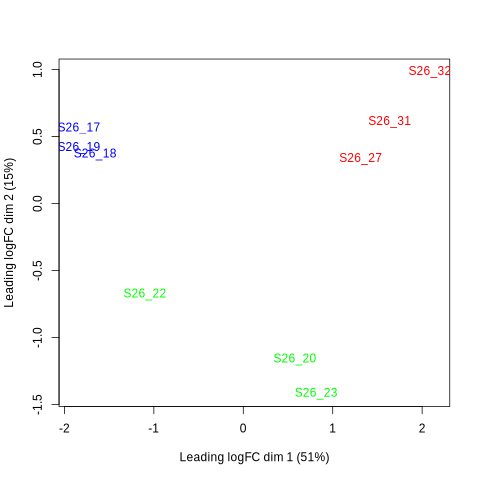

In [47]:
%%R
plotMDS(y, col=ifelse(y$samples$group == "Sham_LNP_circGFP",  "blue", ifelse(y$samples$group == "IRI_LNP_circGFP", "green", "red")))

In [100]:
%%R
png("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/Pseudobulk_biological_coefficient_of_variation_myeloid_cells_plot.png")
plotBCV(y)
dev.off()

png 
  2 


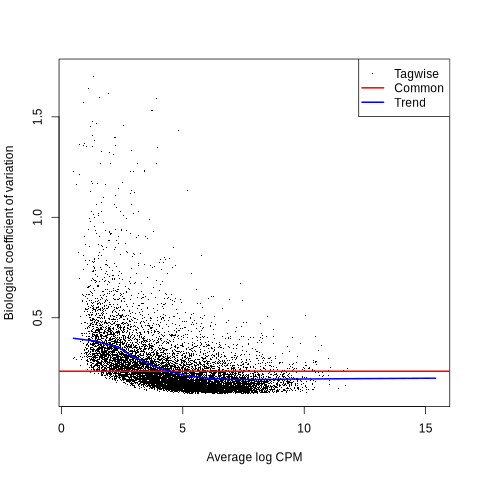

In [48]:
%%R
plotBCV(y)

## Comparison IRI_LNP_circGFP vs Sham_LNP_circGFP

In [49]:
%%R -o tt
# run the test for a specififed contrast
myContrast <- makeContrasts('groupIRI_LNP_circGFP.myeloid_cells-groupSham_LNP_circGFP.myeloid_cells', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table

# filter the results for FDR and logFC
library(dplyr)
print(head(tt))
print(typeof(tt))
tt <- as.data.frame(tt)
print(head(tt))
print(dim(tt[tt$FDR < 0.01,]))

tt_filtered_up <- tt %>%
  filter(FDR < 0.05 & logFC > 1 )


tt_filtered_down <- tt %>%
  filter(FDR < 0.05 & logFC < -1)

# write results
write.csv(tt_filtered_up,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_UP_filtered_groupIRI_LNP_GFP.myeloid_cells-groupSham_LNP_circGFP.myeloid_cells.csv", row.names = TRUE)
write.csv(tt_filtered_down,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_down_filtered_groupIRI_LNP_GFP.myeloid_cells-groupSham_LNP_circGFP.myeloid_cells.csv", row.names = TRUE)
write.csv(tt,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_unfiltered_groupIRI_LNP_GFP.myeloid_cells-groupSham_LNP_circGFP.myeloid_cells.csv", row.names = TRUE)

            logFC   logCPM         F       PValue         FDR
Atg4a    2.302638 6.235866 125.66266 2.763834e-07 0.002240274
Cd200r1  1.760695 6.112753 119.47017 3.556817e-07 0.002240274
Ssh2     1.434309 9.547282 111.96109 4.910011e-07 0.002240274
H2-T23  -1.825906 8.148587  96.07005 1.044337e-06 0.002949715
Plek     1.223971 7.900179  90.67425 1.384957e-06 0.002949715
H2-Q7   -2.070177 7.459032  89.13411 1.505584e-06 0.002949715
[1] "list"
            logFC   logCPM         F       PValue         FDR
Atg4a    2.302638 6.235866 125.66266 2.763834e-07 0.002240274
Cd200r1  1.760695 6.112753 119.47017 3.556817e-07 0.002240274
Ssh2     1.434309 9.547282 111.96109 4.910011e-07 0.002240274
H2-T23  -1.825906 8.148587  96.07005 1.044337e-06 0.002949715
Plek     1.223971 7.900179  90.67425 1.384957e-06 0.002949715
H2-Q7   -2.070177 7.459032  89.13411 1.505584e-06 0.002949715
[1] 811   5


## Comparison IRI_LNP_circINSR vs IRI_LNP_circGFP

In [84]:
%%R -o tt
# run the test for a specififed contrast
myContrast <- makeContrasts('groupIRI_LNP_circINSR.myeloid_cells-groupIRI_LNP_circGFP.myeloid_cells', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table

# filter the results for FDR and logFC
library(dplyr)
print(head(tt))
print(typeof(tt))
tt <- as.data.frame(tt)
print(head(tt))
print(dim(tt[tt$FDR < 0.01,]))

tt_filtered_up <- tt %>%
  filter(FDR < 0.05 & logFC > 1 )


tt_filtered_down <- tt %>%
  filter(FDR < 0.05 & logFC < -1)

# write results
write.csv(tt_filtered_up,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_UP_filtered_groupIRI_LNP_circINSR.myeloid_cells-groupIRI_LNP_circGFP.myeloid_cells.csv", row.names = TRUE)
write.csv(tt_filtered_down,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_down_filtered_groupIRI_LNP_circINSR.myeloid_cells-groupIRI_LNP_circGFP.myeloid_cells.csv", row.names = TRUE)
write.csv(tt,"/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells__DEGs_unfiltered_groupIRI_LNP_circINSR.myeloid_cells-groupIRI_LNP_circGFP.myeloid_cells.csv", row.names = TRUE)

            logFC   logCPM         F       PValue         FDR
Gm47922  4.511042 2.256019 105.67686 2.012646e-07 0.001680228
Ccl5     3.444089 5.247872 128.74643 2.455038e-07 0.001680228
Majin    2.944923 5.861961 111.43584 5.034077e-07 0.002216127
Speg    -5.179264 3.281846  71.46084 6.476115e-07 0.002216127
Cd40     2.356112 6.905559 100.37343 8.425471e-07 0.002306557
Basp1   -1.434772 7.552138  93.17086 1.213254e-06 0.002767836
[1] "list"
            logFC   logCPM         F       PValue         FDR
Gm47922  4.511042 2.256019 105.67686 2.012646e-07 0.001680228
Ccl5     3.444089 5.247872 128.74643 2.455038e-07 0.001680228
Majin    2.944923 5.861961 111.43584 5.034077e-07 0.002216127
Speg    -5.179264 3.281846  71.46084 6.476115e-07 0.002216127
Cd40     2.356112 6.905559 100.37343 8.425471e-07 0.002306557
Basp1   -1.434772 7.552138  93.17086 1.213254e-06 0.002767836
[1] 157   5


## myeloid cells: 1. Intersection IRI_circGFP_UP - IRI_circINSR_DOWN and 2. IRI_circGFP_DOWN-IRI_circINSR_UP

## 1. Intersection IRI_circGFP_UP - IRI_circINSR_DOWN

In [69]:
IRI_circGFP_UP_df = pd.read_csv("/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_UP_filtered_groupIRI_LNP_GFP.myeloid_cells-groupSham_LNP_circGFP.myeloid_cells.csv", index_col = 0)
IRI_circINSR_DOWN_df = pd.read_csv("/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_down_filtered_groupIRI_LNP_circINSR.myeloid_cells-groupIRI_LNP_circGFP.myeloid_cells.csv", index_col = 0)

In [ ]:
IRI_circGFP_UP_IRI_circINSR_DOWN_intersect_df = IRI_circGFP_UP_df.join(IRI_circINSR_DOWN_df, how = "inner", lsuffix="_IRI_circGFP_UP", rsuffix = "_IRI_circINSR_DOWN")

In [73]:
IRI_circGFP_UP_IRI_circINSR_DOWN_intersect_df

,logFC_IRI_circGFP_UP,logCPM_IRI_circGFP_UP,F_IRI_circGFP_UP,PValue_IRI_circGFP_UP,FDR_IRI_circGFP_UP,logFC_IRI_circINSR_DOWN,logCPM_IRI_circINSR_DOWN,F_IRI_circINSR_DOWN,PValue_IRI_circINSR_DOWN,FDR_IRI_circINSR_DOWN
Lhfpl2,1.805638,4.316829,84.224451,0.000002,0.002950,-1.096733,4.316829,32.945225,0.000140,0.010473
Maml3,1.137592,7.338115,56.550391,0.000013,0.004046,-1.120297,7.338115,54.325657,0.000016,0.004178
Spp1,2.888060,5.082303,34.333433,0.000118,0.005993,-2.316236,5.082303,23.008835,0.000586,0.021565
Spon1,2.487272,6.906580,33.630082,0.000128,0.005993,-1.747552,6.906580,17.563621,0.001569,0.033721
Arhgap24,1.768100,6.845140,33.165331,0.000136,0.006063,-1.707950,6.845140,30.549345,0.000191,0.012398
Plau,1.383405,3.738101,28.062621,0.000270,0.007707,-1.619784,3.738101,33.918606,0.000124,0.010373
Scel,3.394903,1.184823,22.042918,0.000366,0.008437,-2.404851,1.184823,12.866097,0.003075,0.047905
Spsb4,2.961209,2.150119,18.425297,0.001203,0.013877,-3.278310,2.150119,18.066655,0.001293,0.031303
Trem2,1.020759,3.119116,16.026635,0.002158,0.018224,-1.178723,3.119116,18.903623,0.001215,0.030287
Col14a1,1.043077,5.618508,10.052514,0.009103,0.041967,-1.353995,5.618508,15.945832,0.002187,0.039197


In [78]:
len(IRI_circGFP_UP_IRI_circINSR_DOWN_intersect_df.index)

11

In [88]:
type(IRI_circGFP_UP_IRI_circINSR_DOWN_intersect_df)

pandas.core.frame.DataFrame

In [89]:
IRI_circGFP_UP_IRI_circINSR_DOWN_intersect_df.to_csv(
    "/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/myeloid_cells_IRI_circGFP_UP_IRI_circINSR_DOWN_intersect_df.csv",
    index=True
)

## 2. IRI_circGFP_DOWN-IRI_circINSR_UP

In [79]:
IRI_circGFP_DOWN_df = pd.read_csv("/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_down_filtered_groupIRI_LNP_GFP.myeloid_cells-groupSham_LNP_circGFP.myeloid_cells.csv", index_col = 0)
IRI_circINSR_UP_df = pd.read_csv("/projects/circ_iri/work/sc_analysis_final/DEG_main_cluster/myeloid_cells/myeloid_cells_DEGs_UP_filtered_groupIRI_LNP_circINSR.myeloid_cells-groupIRI_LNP_circGFP.myeloid_cells.csv", index_col = 0)

In [80]:
IRI_circGFP_DOWN_IRI_circINSR_UP_intersect_df = IRI_circGFP_DOWN_df.join(IRI_circINSR_UP_df, how = "inner", lsuffix="_circGFP_DOWN_df", rsuffix = "_IRI_circINSR_UP")

In [81]:
IRI_circGFP_DOWN_IRI_circINSR_UP_intersect_df

,logFC_circGFP_DOWN_df,logCPM_circGFP_DOWN_df,F_circGFP_DOWN_df,PValue_circGFP_DOWN_df,FDR_circGFP_DOWN_df,logFC_IRI_circINSR_UP,logCPM_IRI_circINSR_UP,F_IRI_circINSR_UP,PValue_IRI_circINSR_UP,FDR_IRI_circINSR_UP
Lag3,-2.598099,2.614458,62.579157,0.000008,0.003818,2.634092,2.614458,61.095535,9.045362e-06,0.004178
Cxcl9,-2.626711,6.611223,51.057027,0.000021,0.004299,2.348942,6.611223,40.817508,5.608052e-05,0.006922
Cadm3,-3.270926,2.401510,35.728849,0.000085,0.005329,2.974132,2.401510,25.863391,3.309681e-04,0.016008
Tapbpl,-1.103333,4.580359,31.633039,0.000166,0.006521,1.026102,4.580359,26.287684,3.496386e-04,0.016337
P4htm,-2.583404,2.085357,30.906252,0.000175,0.006771,1.996508,2.085357,14.761925,2.776419e-03,0.045028
4933406J09Rik,-9.619690,4.068337,35.797060,0.000226,0.007274,9.911719,4.068337,40.028934,1.505199e-04,0.010787
Gm56768,-1.566932,3.024929,29.350938,0.000227,0.007274,1.236204,3.024929,16.136272,2.112978e-03,0.038576
Ccl19-ps2,-3.036054,2.503225,18.147655,0.001328,0.014571,3.057858,2.503225,17.431307,1.533263e-03,0.033332
Gm17066,-1.581600,3.995987,18.233139,0.001378,0.014725,1.599973,3.995987,17.814882,1.495096e-03,0.033153
Scara5,-1.331051,3.831824,18.075943,0.001420,0.014988,1.302000,3.831824,16.404366,1.988972e-03,0.037244


In [82]:
len(IRI_circGFP_DOWN_IRI_circINSR_UP_intersect_df.index)

15

In [90]:
IRI_circGFP_DOWN_IRI_circINSR_UP_intersect_df.to_csv(
    "/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/myeloid_cells_IRI_circGFP_DOWN_IRI_circINSR_UP_intersect_df.csv",
    index=True
)